### DATA
Tento dataset byl získán ze čtyř předních tuzemských realitních webů. Je organizován do čtyř hlavních kategorií: byty, domy, pozemky
a komerční nemovitosti. Každá z těchto kategorií je dále rozdělena do tří podkategorií: aukce, pronájem a prodej.

### Popis Datasetu
Byty: Přibližně 51 000 záznamů s 14 atributy.

- id: Unikátní identifikátor pro každou nabídku bytu.
- building_type: Typ budovy, jako cihlová, panelová nebo jiné typy konstrukce.
- city: Kódovaná reprezentace města, kde se byt nachází.
- condition: Stav bytu (např. nový, dobrý nebo ve výstavbě).
- estate_type: Označuje typ nemovitosti (všechny záznamy se týkají bytů v tomto datasetu).
- floor_space: Celková podlahová plocha bytu, měřená v metrech čtverečních.
- land_space: Pozemek spojený s bytem (často 0 u bytů).
- price: Měsíční nájemné bytu, v místní měně.
- region: Kódovaná reprezentace geografické oblasti.
- sale_type: Označuje, zda je nemovitost k pronájmu, prodeji nebo aukci.
- source: Platforma nebo webová stránka, ze které byla data získána.
- disposition: Dispozice nebo počet místností v bytě (např. 1+kk, 2+1, atd.).
- equipment: Úroveň vybavení bytu (např. nedefinováno, nezařízeno, částečně zařízeno, zařízeno).
- penb: Hodnocení energetického průkazu budovy, kategorizované od A (nejlepší) po G (nejhorší).

### Cíle a Záměry
- Primárním cílem je predikovat nájemné bytů na základě dostupných atributů. Zaměřujeme se na analýzu vlivu různých faktorů, jako jsou:
- Poloha (město a region)
- Velikost bytu (floor_space)
- Stav budovy (condition)
- Úroveň vybavení (equipment)
- Energetická účinnost (penb)
- A další relevantní atributy.

### Hypotéza
- Výše nájemného je výrazně ovlivněna polohou, velikostí a stavem bytu. Další faktory jako úroveň vybavení a energetická účinnost také hrají zásadní roli při určování výše nájemného.

In [155]:
import pandas as pd
import numpy as np
import category_encoders as ce

data = pd.read_csv('data/apartment_properties_RENT.csv')

In [156]:
data

,id,building_type,city,condition,estate_type,floor_space,land_space,price,region,sale_type,source,disposition,equipment,penb
0,845394,UNDEFINED,Mariánské Lázně,UNDEFINED,apartment,20.0,0.0,16340.0,Karlovarský kraj,RENT,bezrealitky,DISP_1_KK,FURNISHED,G
1,600390,PANEL,Brno,VERY_GOOD,apartment,36.0,0.0,9500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_1_KK,PARTIALLY,A
2,843682,BRICK,Brno,VERY_GOOD,apartment,60.0,0.0,20500.0,Jihomoravský kraj,RENT,bezrealitky,DISP_2_1,FURNISHED,G
3,435994,BRICK,Opava,VERY_GOOD,apartment,38.0,0.0,7000.0,Moravskoslezský kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G
4,843695,BRICK,Lipník nad Bečvou,VERY_GOOD,apartment,41.0,0.0,5200.0,Olomoucký kraj,RENT,bezrealitky,DISP_1_1,PARTIALLY,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20654,3488433484,BRICK,Slezská,VERY_GOOD,apartment,40.0,0.0,15000.0,Praha 3 - Vinohrady,RENT,sreality,2+kk,NaN,G
20655,3488122188,BRICK,Na Petřinách,VERY_GOOD,apartment,20.0,0.0,10000.0,Praha - Praha 6,RENT,sreality,NaN,NaN,G
20656,3490301260,BRICK,Újezd,VERY_GOOD,apartment,73.0,0.0,35000.0,Praha 5 - Malá Strana,RENT,sreality,2+kk,NaN,G
20657,3489158476,BRICK,Šimáčkova,NEW,apartment,36.0,0.0,13900.0,Brno - Líšeň,RENT,sreality,2+kk,NaN,G


In [165]:
data_shufled = data.sample(n=len(data), random_state=1)
data_shufled.loc[:, 'condition'] = data_shufled['condition'].fillna('UNDEFINED')
data_shufled.loc[:, 'land_space'] = data_shufled['land_space'].fillna(0)
data_shufled.loc[:, 'disposition'] = data_shufled['disposition'].fillna('UNDEFINED')
data_shufled.loc[:, 'equipment'] = data_shufled['equipment'].fillna('UNDEFINED')
data_shufled.loc[:, 'penb'] = data_shufled['penb'].fillna('G')

data_shufled

,id,building_type,city,condition,estate_type,floor_space,land_space,price,region,sale_type,source,disposition,equipment,penb
2364,845257,SKELET,Praha,NEW,apartment,51.0,0.0,25900.0,Praha,RENT,bezrealitky,DISP_2_KK,FURNISHED,G
8176,621340e32163093e87306f89,BRICK,Nová Bystřice,GOOD,apartment,55.0,0.0,8500.0,Jihočeský kraj,RENT,idnes,UNDEFINED,UNDEFINED,G
16402,896025932,BRICK,Herlíkovická,VERY_GOOD,apartment,85.0,0.0,13790.0,Praha 9 - Kbely,RENT,sreality,1+kk,UNDEFINED,G
20321,3619317068,PANEL,Bronzová,GOOD,apartment,57.0,0.0,15500.0,Praha 5 - Stodůlky,RENT,sreality,1+kk,UNDEFINED,G
10717,3164026188,BRICK,Truhlářská,VERY_GOOD,apartment,77.0,0.0,32364.0,Praha 1 - Nové Město,RENT,sreality,3+kk,UNDEFINED,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,3063174476,BRICK,Riegrova,AFTER_RECONSTRUCTION,apartment,60.0,0.0,15000.0,Olomouc,RENT,sreality,2+1,UNDEFINED,G
17289,566383948,BRICK,Moravská,AFTER_RECONSTRUCTION,apartment,38.0,0.0,24000.0,Praha 2 - Vinohrady,RENT,sreality,2+kk,UNDEFINED,G
5192,65bcd07e87e41d92e602cf24,MIXED,Ústí nad Labem,UNDEFINED,apartment,55.0,0.0,20000.0,Ústecký kraj,RENT,idnes,UNDEFINED,UNDEFINED,G
12172,2579584332,BRICK,Belgická,VERY_GOOD,apartment,95.0,0.0,40000.0,Praha 2 - Vinohrady,RENT,sreality,3+kk,UNDEFINED,G


In [158]:
data_shufled.drop(['estate_type', 'sale_type', 'source', 'id'], axis=1, inplace=True)

In [159]:
data_shufled['building_type'].value_counts()

building_type
BRICK         13413
PANEL          4274
MIXED          1981
SKELET          418
UNDEFINED       297
OTHER            83
STONE            38
ASSEMBLED        26
WOODEN           18
WOOD             10
PREFAB            3
LOW_ENERGY        1
Name: count, dtype: int64

In [160]:
#data_preperation = pd.concat([data_shufled.drop('building_type', axis=1), pd.get_dummies(data_shufled['building_type'])], axis=1)
data_preperation = data_shufled

In [ ]:
# Vytvoření nových atributů
data_preperation['price_per_land_space'] = data_preperation['price'] / (data_preperation['land_space'] + 1)
data_preperation['price_per_land_space'].fillna(0)

data_preperation['price_per_floor_space'] = data_preperation['price'] / (data_preperation['floor_space'] + 1)
data_preperation['price_per_floor_space'].fillna(0)

In [ ]:
# Target/Mean kódování
target_cols = ['city', 'region', 'disposition']
target_encoder = ce.TargetEncoder(cols=target_cols)
data_preperation[target_cols] = target_encoder.fit_transform(data_preperation[target_cols], data_preperation['price'])

In [163]:
data_preperation['condition'].value_counts()

condition
VERY_GOOD                6150
UNDEFINED                5854
GOOD                     3600
AFTER_RECONSTRUCTION     2539
NEW                      2436
BEFORE_RECONSTRUCTION      23
MAINTAINED                 22
UNDER_CONSTRUCTION         15
UNDER_RECONSTRUCTION       10
PROJECT                     7
BAD                         1
IN_RECONSTRUCTION           1
CONSTRUCTION                1
Name: count, dtype: int64

In [ ]:
#One Hot kódování
#data_preperation = pd.concat([data_preperation.drop('condition', axis=1), pd.get_dummies(data_preperation['condition'])],axis=1)

In [131]:
data_preperation['equipment'].value_counts()

equipment
UNDEFINED      18572
FURNISHED        963
PARTIALLY        867
UNFURNISHED      257
Name: count, dtype: int64

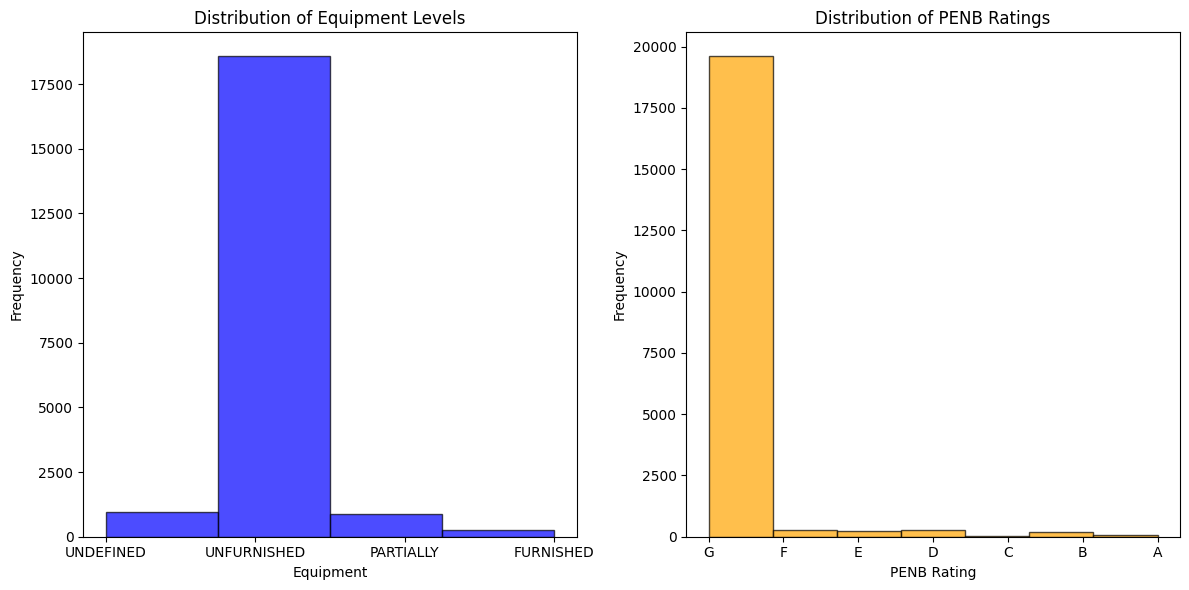

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(data_preperation['equipment'], bins=4, edgecolor='black', color='blue', alpha=0.7)
plt.xticks([0, 1, 2, 3], ['UNDEFINED', 'UNFURNISHED', 'PARTIALLY', 'FURNISHED'])
plt.xlabel('Equipment')
plt.ylabel('Frequency')
plt.title('Distribution of Equipment Levels')

plt.subplot(1, 2, 2)
plt.hist(data_preperation['penb'], bins=7, edgecolor='black', color='orange', alpha=0.7)
plt.xticks(range(7), ['G', 'F', 'E', 'D', 'C', 'B', 'A'])
plt.xlabel('PENB Rating')
plt.ylabel('Frequency')
plt.title('Distribution of PENB Ratings')

plt.tight_layout()
plt.show()

In [ ]:
# Ordinální kódování
equipment_mapping = {'UNDEFINED': 0, 'UNFURNISHED': 1, 'PARTIALLY': 2, 'FURNISHED': 3}
penb_mapping = {'G': 0, 'F': 1, 'E': 2, 'D': 3, 'C': 4, 'B': 5, 'A': 6}

data_preperation['equipment'] = data_preperation['equipment'].map(equipment_mapping)
data_preperation['penb'] = data_preperation['penb'].map(penb_mapping)

In [134]:
data_preperation

,building_type,city,condition,floor_space,land_space,price,region,disposition,equipment,penb,price_per_land_space,price_per_floor_space
2364,SKELET,27316.454188,NEW,51.0,0.0,25900.0,26343.168919,20545.931667,3,0,25900.0,498.076923
8176,BRICK,17172.702223,GOOD,55.0,0.0,8500.0,12256.793451,17707.306563,0,0,8500.0,151.785714
16402,BRICK,18190.792253,VERY_GOOD,85.0,0.0,13790.0,18952.810484,13100.679621,0,0,13790.0,160.348837
20321,PANEL,18338.488893,GOOD,57.0,0.0,15500.0,22964.596450,13100.679621,0,0,15500.0,267.241379
10717,BRICK,42758.150113,VERY_GOOD,77.0,0.0,32364.0,44831.888284,30951.278135,0,0,32364.0,414.923077
...,...,...,...,...,...,...,...,...,...,...,...,...
10955,BRICK,15790.902257,AFTER_RECONSTRUCTION,60.0,0.0,15000.0,15764.332361,13660.433775,0,0,15000.0,245.901639
17289,BRICK,19311.092178,AFTER_RECONSTRUCTION,38.0,0.0,24000.0,40064.251656,18754.046573,0,0,24000.0,615.384615
5192,MIXED,9739.325491,UNDEFINED,55.0,0.0,20000.0,10423.133929,17707.306563,0,0,20000.0,357.142857
12172,BRICK,25874.883050,VERY_GOOD,95.0,0.0,40000.0,40064.251656,30951.278135,0,0,40000.0,416.666667


In [135]:
data_preperation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20659 entries, 2364 to 235
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   building_type          20562 non-null  object 
 1   city                   20632 non-null  float64
 2   condition              20659 non-null  object 
 3   floor_space            20656 non-null  float64
 4   land_space             20659 non-null  float64
 5   price                  20517 non-null  float64
 6   region                 20656 non-null  float64
 7   disposition            20659 non-null  float64
 8   equipment              20659 non-null  int64  
 9   penb                   20659 non-null  int64  
 10  price_per_land_space   20517 non-null  float64
 11  price_per_floor_space  20514 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 2.0+ MB


In [136]:
data_preperation.dropna(inplace=True)

In [137]:
data_preperation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20423 entries, 2364 to 235
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   building_type          20423 non-null  object 
 1   city                   20423 non-null  float64
 2   condition              20423 non-null  object 
 3   floor_space            20423 non-null  float64
 4   land_space             20423 non-null  float64
 5   price                  20423 non-null  float64
 6   region                 20423 non-null  float64
 7   disposition            20423 non-null  float64
 8   equipment              20423 non-null  int64  
 9   penb                   20423 non-null  int64  
 10  price_per_land_space   20423 non-null  float64
 11  price_per_floor_space  20423 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 2.0+ MB


In [138]:
df = data_preperation.drop('price', axis=1)
y = data_preperation['price']

In [139]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

numeric_features = df.select_dtypes(include=[np.number]).columns
categorical_features = ['condition', 'building_type'] 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
        ]), categorical_features)
    ]
)

X_preprocessed = preprocessor.fit_transform(df)

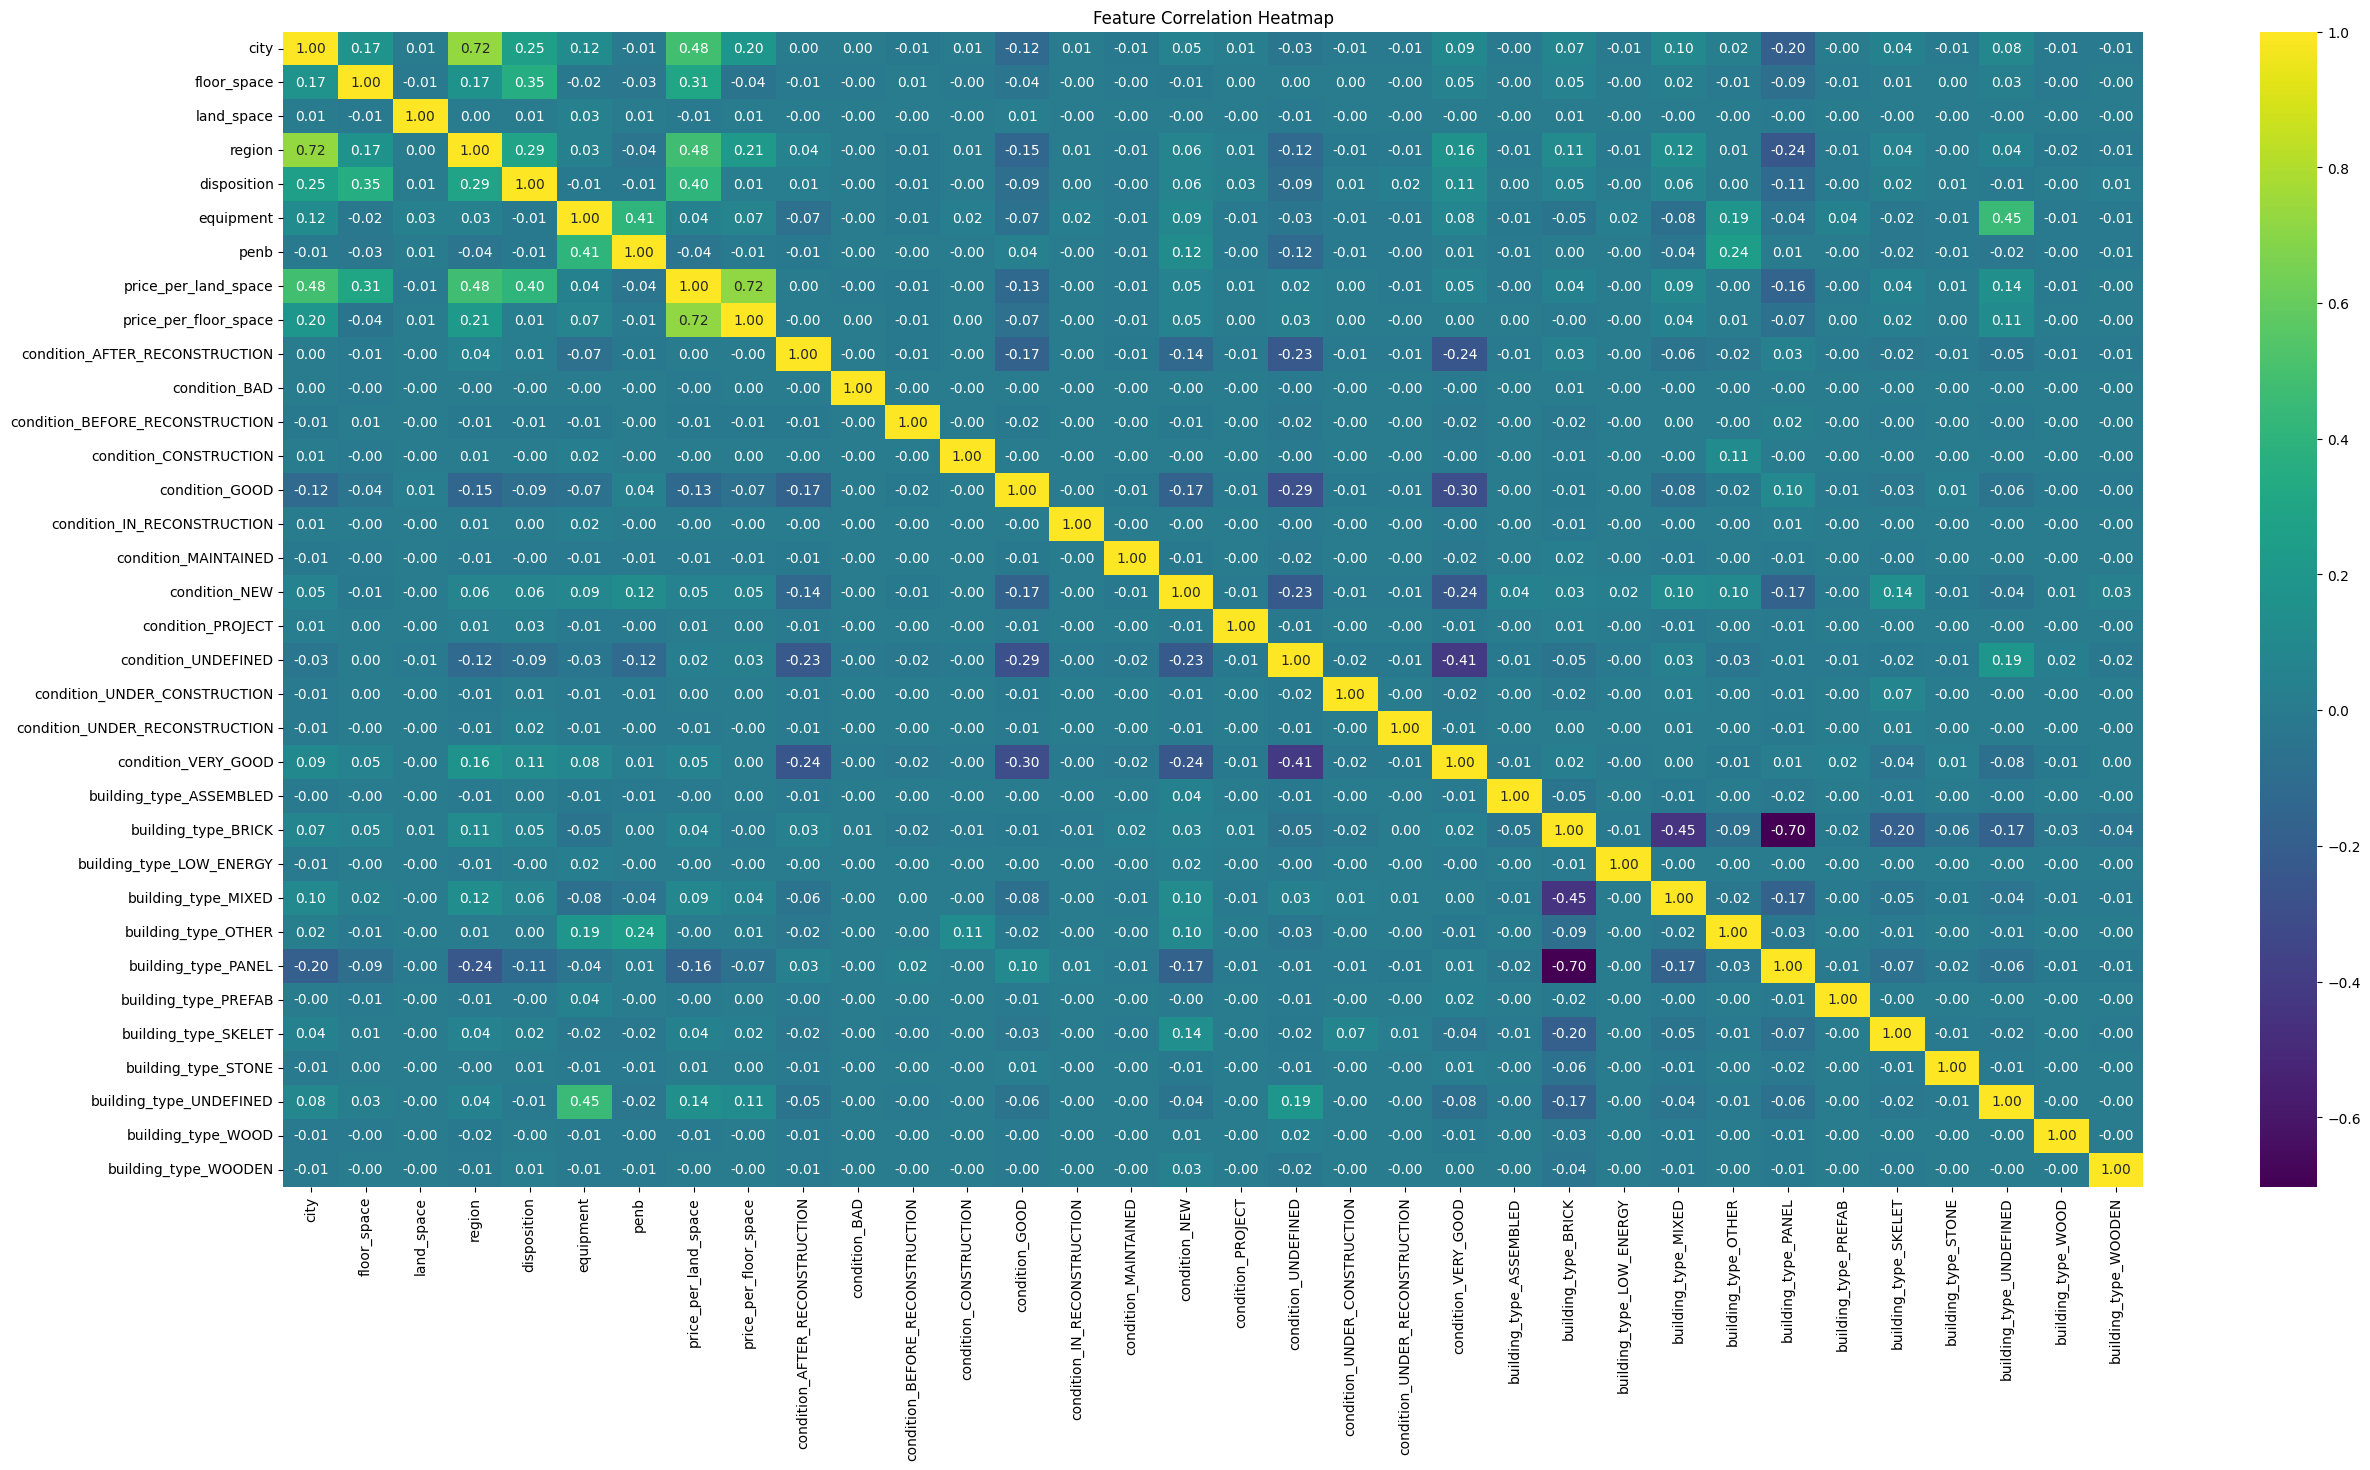

In [147]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_feature_names = numeric_features

categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)

X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)

correlation_matrix = X_preprocessed_df.corr()

plt.figure(figsize=(30, 15))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import scipy.stats

#Strojové učení pomocí gradient boostingu

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=10000, 
    early_stopping_rounds=20, 
    n_jobs=-1,
    random_state=42
)

param_distributions = {
    "learning_rate": scipy.stats.uniform(loc=0.01, scale=0.2),  
    "subsample": scipy.stats.uniform(loc=0.5, scale=0.5),  
    "colsample_bytree": scipy.stats.uniform(loc=0.5, scale=0.5), 
    "min_child_weight": [1, 3, 5, 7],
    "max_depth": np.arange(3, 10), 
    "reg_alpha": [0, 0.1, 1, 5, 10],  
    "reg_lambda": [1, 5, 10, 20] 
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40, 
    cv=3,  
    scoring="neg_mean_absolute_error",  
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], 
    verbose=False,
)

tuned_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

print("Tuned model performance:")
print("R^2:", r2_score(y_test, tuned_model.predict(X_test)))
print("MAE:", mean_absolute_error(y_test, tuned_model.predict(X_test)))

optimal_params = random_search.best_params_
optimal_params["n_estimators"] = tuned_model.best_iteration  
final_model = xgb.XGBRegressor(**optimal_params, random_state=42, n_jobs=-1)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Final re-trained model performance:")
print("R^2:", r2_score(y_test, final_model.predict(X_test)))
print("MAE:", mean_absolute_error(y_test, final_model.predict(X_test)))

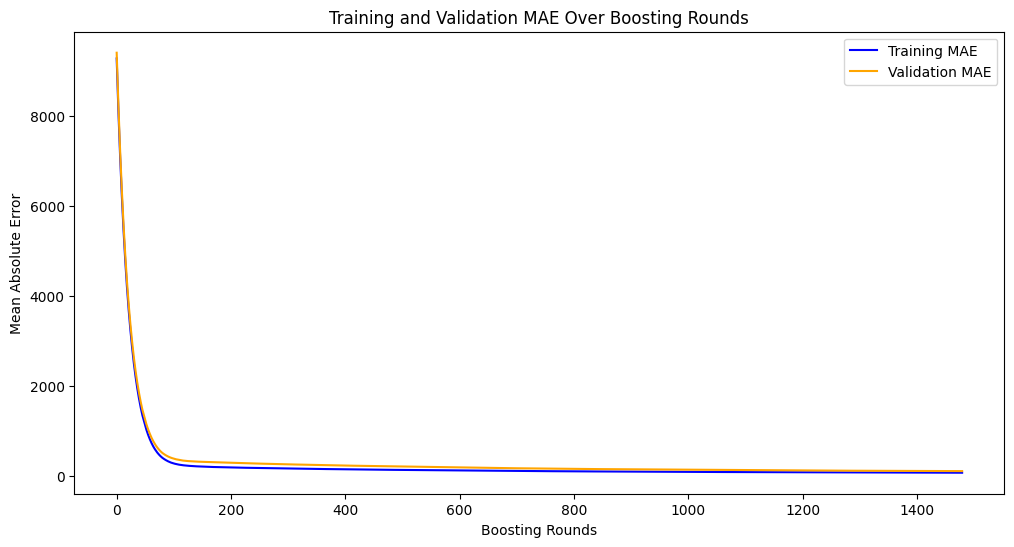

In [22]:
import matplotlib.pyplot as plt

final_model = xgb.XGBRegressor(
    **optimal_params,
    random_state=42,
    n_jobs=-1,
    eval_metric="mae",
    early_stopping_rounds=20,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],  
    verbose=False
)

eval_results = final_model.evals_result()

train_loss = eval_results['validation_0']['mae']
val_loss = eval_results['validation_1']['mae']

plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Training MAE', color='blue')
plt.plot(val_loss, label='Validation MAE', color='orange')
plt.xlabel('Boosting Rounds')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training and Validation MAE Over Boosting Rounds')
plt.show()

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

#Vícevrstvý perceptron

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

large_nn = Sequential()
large_nn.add(InputLayer(shape=(X_train_scaled.shape[1],)))
large_nn.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
large_nn.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
large_nn.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
large_nn.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
large_nn.add(Dense(1, activation='linear'))

opt = Adam(learning_rate=0.001)
cp = ModelCheckpoint('rent/prediction_rent_school.keras', save_best_only=True, monitor='val_loss', mode='min')
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

large_nn.compile(optimizer=opt, loss='mae', metrics=[MeanAbsoluteError()])

history = large_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=25,
    batch_size=4,
    callbacks=[cp, es, rlr]
)

y_pred = large_nn.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.title('Training and Validation Loss Over Epochs')
plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout, Conv2D, Flatten, Reshape
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2

#Konvoluční neuronová síť

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

num_features = X_preprocessed.shape[1]
X_train_cnn = X_train_scaled.reshape(-1, num_features, 1, 1)  
X_val_cnn = X_val_scaled.reshape(-1, num_features, 1, 1)
X_test_cnn = X_test_scaled.reshape(-1, num_features, 1, 1)

cnn = Sequential()
cnn.add(InputLayer(shape=(num_features, 1, 1)))
cnn.add(Conv2D(filters=16, kernel_size=(3, 1), activation='relu'))
cnn.add(Conv2D(filters=32, kernel_size=(3, 1), activation='relu'))
cnn.add(Flatten())
cnn.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
cnn.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
cnn.add(Dense(1, activation='linear'))

opt = Adam(learning_rate=0.0005)
cp = ModelCheckpoint('rent/prediction_rent_cnn.keras', save_best_only=True, monitor='val_loss', mode='min')
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

cnn.compile(optimizer=opt, loss='mae', metrics=['mae'])

history = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=25,
    batch_size=4,
    callbacks=[cp, es, rlr]
)

y_pred = cnn.predict(X_test_cnn)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.title('Training and Validation Loss Over Epochs (CNN)')
plt.show()

### Závěry
#### Gradient Boosting s XGBoost
- Výkon: Dosažená průměrná absolutní chyba (MAE) byla 108.6925, což je nejvyšší hodnota ve srovnání s neuronovou sítí (NN) a konvoluční neuronovou sítí (CNN).
- Trénování vs. Validace: Trénovací a validační chyby plynule konvergovaly během boosting kol, což naznačuje, že model není přetrénovaný ani podtrénovaný.
- Ladění hyperparametrů: RandomizedSearchCV() pomohlo optimalizovat hyperparametry jako learning rate, hloubka stromu a regularizace, což vedlo k efektivnímu modelu.

#### Neuronová Síť - Vícevrstvý Perceptron
- Výkon: Model dosáhl MAE 71.23, což je výrazné zlepšení oproti XGBoost.
- Trénování vs. Validace: Graf ukazuje klesající trend pro trénovací i validační ztráty, i když existuje prostor pro zlepšení.

#### Konvoluční Neuronová Síť
- Výkon: CNN dosáhla nejnižší MAE 67.39, což z ní činí nejlépe fungující model pro tento dataset.
- Trénování vs. Validace: Trénovací a validační ztráty následovaly úzce sladěný klesající trend, což je výrazně lepší než u předchozí použité neuronové sítě.

#### Celkové srovnání
- Nejlepší model: CNN dosáhla nejlepší MAE 67.39
- XGBoost je rychlejší na trénování a interpretaci, ale méně efektivní při zachycování složitých vztahů